In [1]:
## Algoritmic Trading with ML

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
plt.style.use("dark_background")

In [2]:
# 1. Veri Çekme (Saatlik - H1)
ticker = 'AAPL'
data = yf.download(ticker, period='2y', interval='1h')


[*********************100%***********************]  1 of 1 completed


In [4]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2024-04-11 13:30:00+00:00,168.720001,169.169998,168.160095,168.250000,9488061
2024-04-11 14:30:00+00:00,169.000000,169.419998,168.570007,168.729996,7020839
2024-04-11 15:30:00+00:00,169.910004,170.289993,169.000000,169.001099,5616006
2024-04-11 16:30:00+00:00,172.104996,172.190002,169.839996,169.919998,9777671
2024-04-11 17:30:00+00:00,174.179993,174.479996,171.960098,172.110001,15507718
...,...,...,...,...,...
2026-04-10 15:30:00+00:00,260.535095,261.750000,260.429993,261.319885,2476645
2026-04-10 16:30:00+00:00,259.239990,260.559998,259.200012,260.545013,2249096


In [5]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

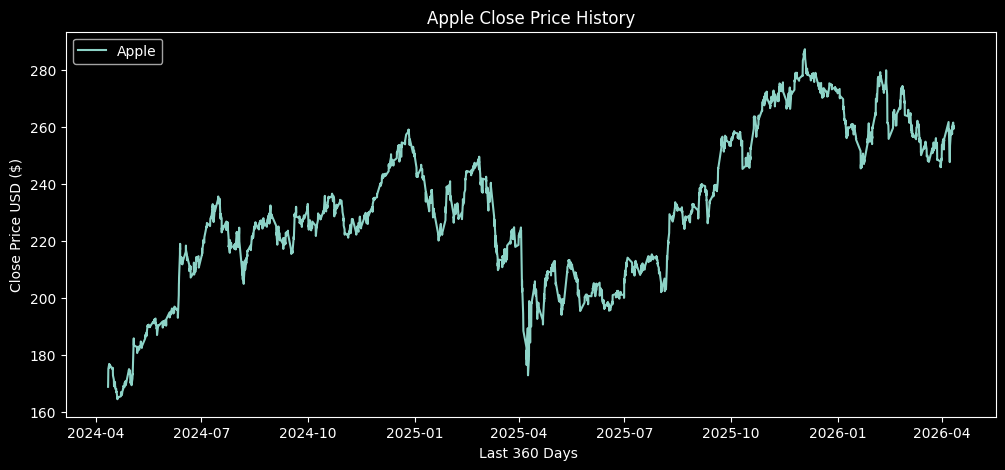

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(data['Close'], label='Apple')
plt.title('Apple Close Price History')
plt.xlabel("Last 360 Days ")
plt.ylabel("Close Price USD ($)")
plt.legend(loc="upper left")
plt.show()

In [7]:
# 2. Supertrend Hesaplama Fonksiyonu
def get_supertrend(df, period=10, multiplier=3):
    # Serileri kopyalayarak ve indexleri sıfırlamayarak garantiye alıyoruz
    high = df['High'].copy()
    low = df['Low'].copy()
    close = df['Close'].copy()
    
    # ATR Hesaplama
    tr1 = high - low
    tr2 = abs(high - close.shift(1))
    tr3 = abs(low - close.shift(1))
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/period, adjust=False).mean()

    hl2 = (high + low) / 2
    upperband = hl2 + (multiplier * atr)
    lowerband = hl2 - (multiplier * atr)
    
    final_upperband = upperband.copy()
    final_lowerband = lowerband.copy()
    supertrend = pd.Series([True] * len(df), index=df.index)

    for i in range(1, len(df)):
        # Üst Band
        if close.iloc[i-1] <= final_upperband.iloc[i-1]:
            final_upperband.iloc[i] = min(upperband.iloc[i], final_upperband.iloc[i-1])
        else:
            final_upperband.iloc[i] = upperband.iloc[i]
        
        # Alt Band
        if close.iloc[i-1] >= final_lowerband.iloc[i-1]:
            final_lowerband.iloc[i] = max(lowerband.iloc[i], final_lowerband.iloc[i-1])
        else:
            final_lowerband.iloc[i] = lowerband.iloc[i]
        
        # Trend (Karşılaştırma hatasını önlemek için .iloc kullanıyoruz)
        if close.iloc[i] <= final_upperband.iloc[i]:
            supertrend.iloc[i] = True
        else:
            supertrend.iloc[i] = False
            
    return final_upperband, final_lowerband, supertrend

In [8]:
# 3. İndikatörleri Uygulama
data['SMA30'] = data['Close'].rolling(window=30).mean()
data['SMA100'] = data['Close'].rolling(window=100).mean()
data['Upper'], data['Lower'], data['ST_Trend'] = get_supertrend(data)
data['ST_Line'] = np.where(data['ST_Trend'], data['Upper'], data['Lower'])

In [9]:
# 4. Sinyaller
data['Buy_Signal'] = np.where((data['ST_Trend'] == False) & (data['ST_Trend'].shift(1) == True), data['Close'], np.nan)
data['Sell_Signal'] = np.where((data['ST_Trend'] == True) & (data['ST_Trend'].shift(1) == False), data['Close'], np.nan)

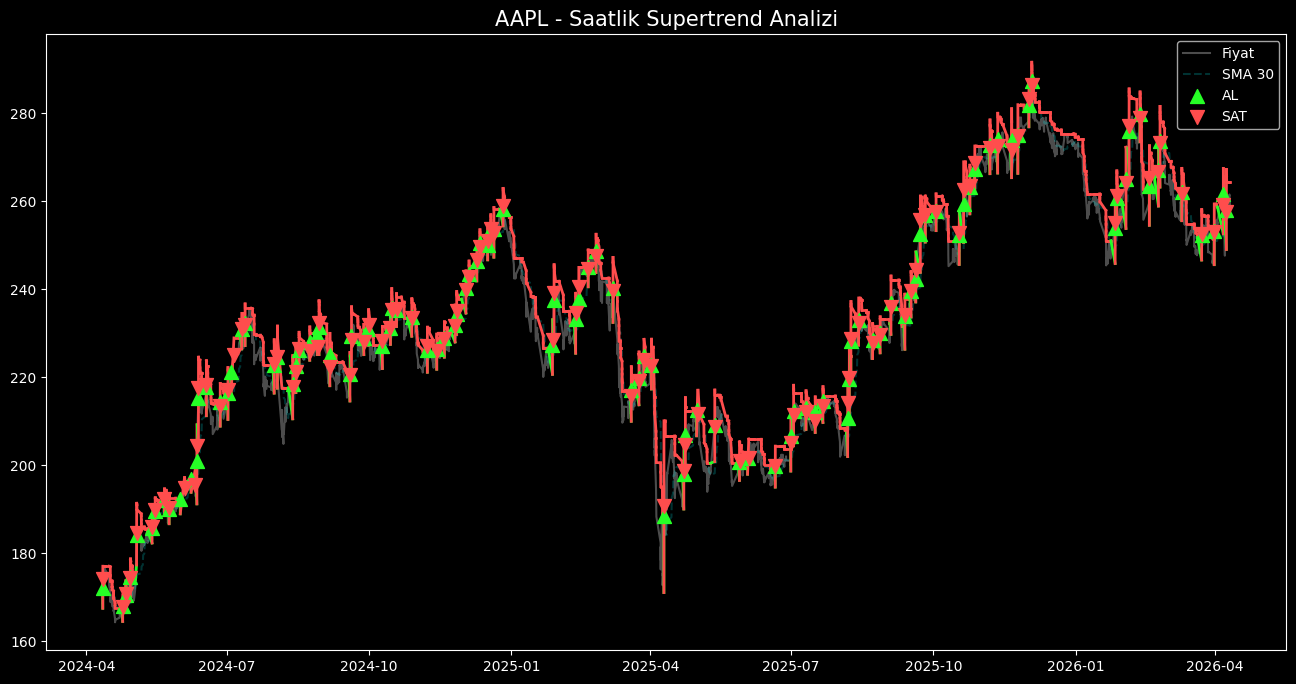

In [10]:
# 5. Görselleştirme
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(data.index, data['Close'], label='Fiyat', color='white', alpha=0.3)
ax.plot(data['SMA30'], label='SMA 30', color='cyan', alpha=0.2, linestyle='--')

# Hızlı çizim için maskeleme
st_line = data['ST_Line']
is_up = ~data['ST_Trend']
is_down = data['ST_Trend']

# Trend çizgilerini renklendirerek çizme
for i in range(1, len(data)):
    color = '#ff4d4d' if data['ST_Trend'].iloc[i] else '#26ff26'
    ax.plot(data.index[i-1:i+1], data['ST_Line'].iloc[i-1:i+1], color=color, linewidth=2)

ax.scatter(data.index, data['Buy_Signal'], label='AL', marker='^', color='#26ff26', s=100, zorder=5)
ax.scatter(data.index, data['Sell_Signal'], label='SAT', marker='v', color='#ff4d4d', s=100, zorder=5)

ax.set_title(f"{ticker} - Saatlik Supertrend Analizi", fontsize=15)
ax.legend()
plt.show()